2025/10/09 12:07:16 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing XGBoost using PSO...


2025/10/09 12:07:33 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7347738788371266, Global best: -0.7347738788371266, Runtime: 9.05102 seconds
2025/10/09 12:07:42 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7393182942072527, Global best: -0.7393182942072527, Runtime: 8.13809 seconds
2025/10/09 12:07:50 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7393182942072527, Global best: -0.7393182942072527, Runtime: 7.88721 seconds
2025/10/09 12:07:57 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7393182942072527, Global best: -0.7393182942072527, Runtime: 7.15127 seconds
2025/10/09 12:08:02 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7429600389645566, Global best: -0.7429600389645566, Runtime: 5.30621 seconds
2025/10/09 12:08:02 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

PSO Accuracy: 0.7430
PSO Best Params: {'n_estimators': 24, 'learning_rate': 0.422, 'max_depth': 6}

Optimizing XGBoost using GA...


2025/10/09 12:08:17 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 6.81190 seconds
2025/10/09 12:08:22 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 5.05020 seconds
2025/10/09 12:08:33 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 10.65403 seconds
2025/10/09 12:08:43 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 9.78079 seconds
2025/10/09 12:08:50 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 7.29369 seconds
2025/10/09 12:08:50 AM, INFO, mealpy.swarm_based.BA.OriginalBA: Origi

GA Accuracy: 0.7384
GA Best Params: {'n_estimators': 60, 'learning_rate': 0.297, 'max_depth': 9}

Optimizing XGBoost using Bat...


2025/10/09 12:09:12 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.736138135317345, Global best: -0.736138135317345, Runtime: 14.24397 seconds
2025/10/09 12:09:28 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.736138135317345, Global best: -0.736138135317345, Runtime: 15.41966 seconds
2025/10/09 12:09:43 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.7365947512157787, Global best: -0.7365947512157787, Runtime: 15.31135 seconds
2025/10/09 12:09:58 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.7375030130436836, Global best: -0.7375030130436836, Runtime: 15.18600 seconds
2025/10/09 12:10:14 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.7375030130436836, Global best: -0.7375030130436836, Runtime: 15.83845 seconds


Bat Accuracy: 0.7375
Bat Best Params: {'n_estimators': 94, 'learning_rate': 0.173, 'max_depth': 6}



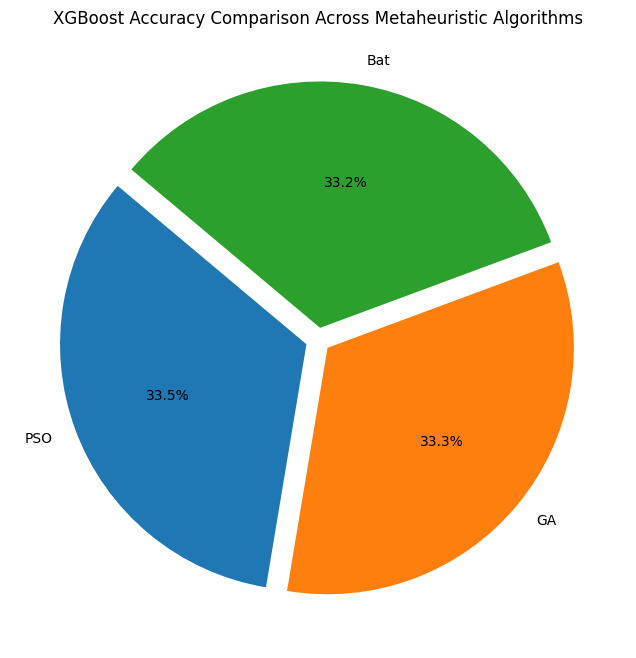

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# XGBoost Objective Function
# ----------------------------
def xgb_objective_function(solution):
    n_estimators = int(solution[0])
    learning_rate = solution[1]
    max_depth = int(solution[2])
    
    try:
        if n_estimators < 1:
            n_estimators = 50
        if learning_rate <= 0:
            learning_rate = 0.1
        if max_depth < 1:
            max_depth = 3
            
        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        )
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Minimize negative accuracy
    except:
        fitness = 1.0
    
    return fitness

# ----------------------------
# XGBoost Problem Definition
# ----------------------------
xgb_problem = {
    "bounds": [
        FloatVar(lb=10, ub=200, name="n_estimators"),      # Number of trees
        FloatVar(lb=0.01, ub=1.0, name="learning_rate"),  # Learning rate
        FloatVar(lb=1, ub=10, name="max_depth")           # Max depth of each tree
    ],
    "minmax": "min",
    "obj_func": xgb_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing XGBoost using {name}...")
    best_agent = optimizer.solve(xgb_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'n_estimators': int(best_solution[0]),
        'learning_rate': round(best_solution[1], 3),
        'max_depth': int(best_solution[2])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("XGBoost Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()


2025/10/09 08:31:40 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing XGBoost using PSO...


2025/10/09 08:32:26 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7397773950901675, Global best: -0.7397773950901675, Runtime: 18.33909 seconds
2025/10/09 08:32:47 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7406875206564335, Global best: -0.7406875206564335, Runtime: 21.35877 seconds
2025/10/09 08:33:08 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7406875206564335, Global best: -0.7406875206564335, Runtime: 20.40529 seconds
2025/10/09 08:33:27 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7406875206564335, Global best: -0.7406875206564335, Runtime: 19.83201 seconds
2025/10/09 08:33:43 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7406875206564335, Global best: -0.7406875206564335, Runtime: 15.67988 seconds
2025/10/09 08:33:43 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: Bas

PSO Accuracy: 0.7407
PSO Best Params: {'learning_rate': 0.078, 'n_estimators': 427, 'max_depth': 2, 'subsample': 0.92, 'colsample_bytree': 0.74}

Optimizing XGBoost using GA...


2025/10/09 08:34:13 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.735682761911152, Global best: -0.735682761911152, Runtime: 14.92601 seconds
2025/10/09 08:34:29 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.735682761911152, Global best: -0.735682761911152, Runtime: 16.21996 seconds
2025/10/09 08:34:51 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7370482608836108, Global best: -0.7370482608836108, Runtime: 22.12908 seconds
2025/10/09 08:35:09 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7415995099610603, Global best: -0.7415995099610603, Runtime: 18.13240 seconds
2025/10/09 08:35:24 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7415995099610603, Global best: -0.7415995099610603, Runtime: 14.88861 seconds
2025/10/09 08:35:24 AM, INFO, mealpy.swarm_based.BA.OriginalBA: Origi

...

CSO Accuracy: 0.7416
CSO Best Params: {'learning_rate': 0.259, 'n_estimators': 71, 'max_depth': 6, 'subsample': 0.78, 'colsample_bytree': 0.61}

Optimizing XGBoost using FA...


2025/10/09 09:10:09 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.7411441365548672, Global best: -0.7411441365548672, Runtime: 599.56183 seconds
2025/10/09 09:15:12 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.7456929006478354, Global best: -0.7456929006478354, Runtime: 303.37963 seconds
2025/10/09 09:19:15 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.7456929006478354, Global best: -0.7456929006478354, Runtime: 242.70821 seconds
2025/10/09 09:23:03 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.7456929006478354, Global best: -0.7456929006478354, Runtime: 227.92191 seconds
2025/10/09 09:27:53 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.7461482740540285, Global best: -0.7461482740540285, Runtime: 290.12919 seconds
2025/10/09 09:27:53 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalA

FA Accuracy: 0.7461
FA Best Params: {'learning_rate': 0.246, 'n_estimators': 60, 'max_depth': 7, 'subsample': 0.68, 'colsample_bytree': 0.87}

Optimizing XGBoost using ABC...


2025/10/09 09:29:13 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.7388685120161425, Global best: -0.7388685120161425, Runtime: 48.95246 seconds
2025/10/09 09:30:02 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.742509014281206, Global best: -0.742509014281206, Runtime: 48.22175 seconds
2025/10/09 09:30:51 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.742509014281206, Global best: -0.742509014281206, Runtime: 48.91462 seconds
2025/10/09 09:31:48 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.742509014281206, Global best: -0.742509014281206, Runtime: 57.49886 seconds
2025/10/09 09:34:18 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.7429656301796396, Global best: -0.7429656301796396, Runtime: 150.31542 seconds


ABC Accuracy: 0.7430
ABC Best Params: {'learning_rate': 0.14, 'n_estimators': 246, 'max_depth': 3, 'subsample': 1.0, 'colsample_bytree': 0.57}



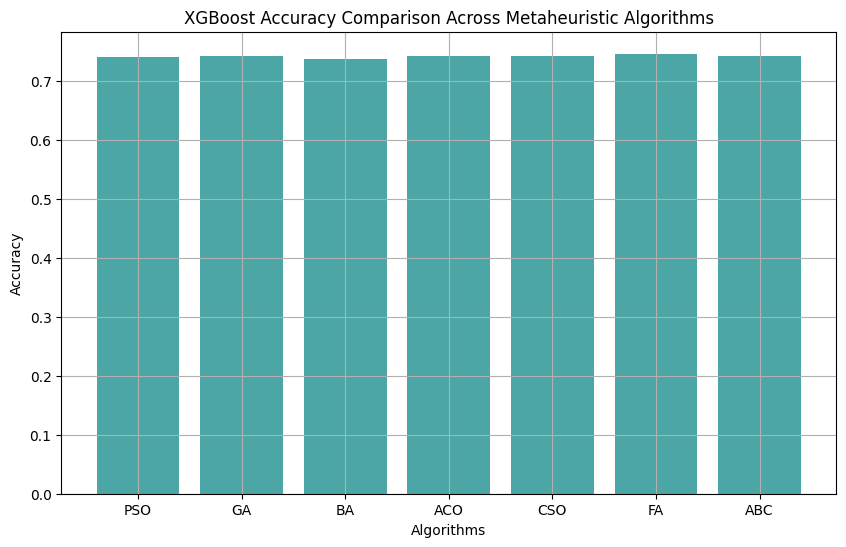

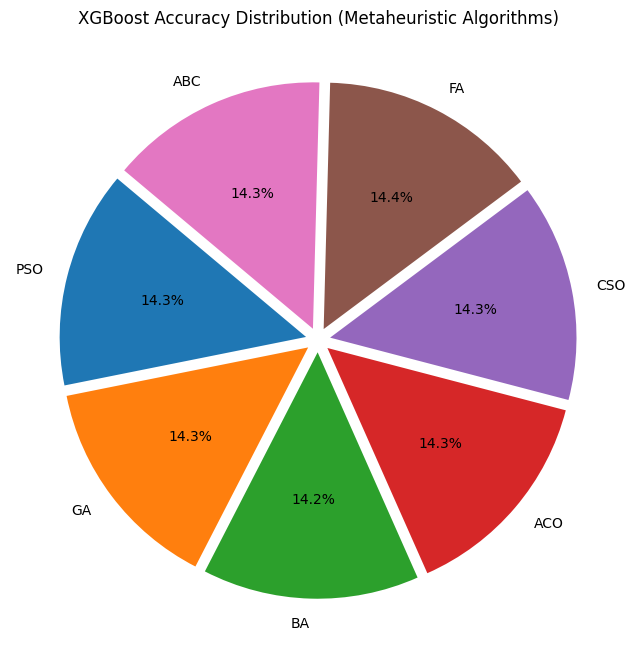

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier

# ----------------------------
# Mealpy imports
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings("ignore")

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    df = pd.concat([amazon, imdb, yelp], axis=0)

    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values

    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# XGBoost Objective Function
# ----------------------------
def xgb_objective_function(solution):
    learning_rate = solution[0]
    n_estimators = int(solution[1])
    max_depth = int(solution[2])
    subsample = solution[3]
    colsample_bytree = solution[4]
    try:
        model = XGBClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss",
        )
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
        fitness = -np.mean(scores)
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# Problem Definition
# ----------------------------
xgb_problem = {
    "bounds": [
        FloatVar(lb=0.01, ub=0.3, name="learning_rate"),
        FloatVar(lb=50, ub=500, name="n_estimators"),
        FloatVar(lb=2, ub=10, name="max_depth"),
        FloatVar(lb=0.5, ub=1.0, name="subsample"),
        FloatVar(lb=0.5, ub=1.0, name="colsample_bytree"),
    ],
    "minmax": "min",
    "obj_func": xgb_objective_function,
}

# ----------------------------
# Metaheuristic Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "BA": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "CSO": CSO.OriginalCSO(epoch=5, pop_size=10),
    "FA": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10),
}

# ----------------------------
# Run Optimization
# ----------------------------
xgb_results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing XGBoost using {name}...")
    best_agent = optimizer.solve(xgb_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness

    best_params = {
        "learning_rate": round(best_solution[0], 3),
        "n_estimators": int(best_solution[1]),
        "max_depth": int(best_solution[2]),
        "subsample": round(best_solution[3], 2),
        "colsample_bytree": round(best_solution[4], 2),
    }

    xgb_results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Bar Chart of Accuracy
# ----------------------------
plt.figure(figsize=(10, 6))
plt.bar(xgb_results.keys(), xgb_results.values(), color='teal', alpha=0.7)
plt.title("XGBoost Accuracy Comparison Across Metaheuristic Algorithms")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# ----------------------------
# Pie Chart of Accuracy
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(
    xgb_results.values(),
    labels=xgb_results.keys(),
    autopct="%1.1f%%",
    startangle=140,
    explode=[0.05] * len(xgb_results),
)
plt.title("XGBoost Accuracy Distribution (Metaheuristic Algorithms)")
plt.show()


In [1]:
# ===============================================
#   BERT (bert-base-uncased) + Metaheuristic Optimization + XGBoost
#   (with caching + GPU + Visualization)
# ===============================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
import torch
from transformers import BertTokenizer, BertModel
import os

# ----------------------------
# Mealpy algorithm imports
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')


# ======================================================
# STEP 1: Load dataset + Use BERT for vectorization (with caching)
# ======================================================
def load_data_with_bert(cache_X="bert_base_embeddings.npy", cache_y="bert_base_labels.npy"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"⚙️ Using device: {device}")

    if os.path.exists(cache_X) and os.path.exists(cache_y):
        print("✅ Loading cached BERT embeddings from disk...")
        X = np.load(cache_X)
        y = np.load(cache_y)
    else:
        print("🔄 Generating new BERT embeddings (first run)...")

        amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
        imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
        yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
        df = pd.concat([amazon, imdb, yelp], axis=0).reset_index(drop=True)

        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        model = BertModel.from_pretrained('bert-base-uncased').to(device)

        def get_bert_embeddings(texts, batch_size=16):
            embeddings = []
            model.eval()
            with torch.no_grad():
                for i in range(0, len(texts), batch_size):
                    batch = texts[i:i+batch_size]
                    encoded = tokenizer(
                        batch, padding=True, truncation=True,
                        max_length=128, return_tensors='pt'
                    ).to(device)
                    outputs = model(**encoded)
                    batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu()
                    embeddings.append(batch_embeddings)
            return torch.cat(embeddings).numpy()

        print("⚙️ Computing embeddings using BERT (this may take several minutes)...")
        X = get_bert_embeddings(df["text"].tolist())
        y = df["label"].values

        np.save(cache_X, X)
        np.save(cache_y, y)
        print(f"💾 Saved embeddings → {cache_X}, {cache_y}")

    print("✅ BERT embeddings ready!")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test


# ======================================================
# STEP 2: Load Data
# ======================================================
X_train, X_test, y_train, y_test = load_data_with_bert()


# ======================================================
# STEP 3: Objective Function for XGBoost
# ======================================================
def xgb_objective_function(solution):
    n_estimators = int(solution[0])
    learning_rate = float(solution[1])
    max_depth = int(solution[2])
    subsample = float(solution[3])
    colsample_bytree = float(solution[4])

    try:
        xgb = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            objective='binary:logistic',
            random_state=42,
            n_jobs=-1,
            use_label_encoder=False,
            eval_metric='logloss',
            tree_method='gpu_hist' if torch.cuda.is_available() else 'hist'
        )
        scores = cross_val_score(xgb, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
        fitness = -np.mean(scores)  # Mealpy minimizes, so negate accuracy
    except Exception as e:
        print(f"⚠️ Error: {e}")
        fitness = 1.0
    return fitness


# ======================================================
# STEP 4: Define Optimization Problem
# ======================================================
xgb_problem = {
    "bounds": [
        FloatVar(lb=50, ub=300, name="n_estimators"),          # Number of trees
        FloatVar(lb=0.01, ub=0.3, name="learning_rate"),       # Learning rate
        FloatVar(lb=2, ub=10, name="max_depth"),               # Tree depth
        FloatVar(lb=0.5, ub=1.0, name="subsample"),            # Row sampling
        FloatVar(lb=0.5, ub=1.0, name="colsample_bytree")      # Column sampling
    ],
    "minmax": "min",
    "obj_func": xgb_objective_function
}


# ======================================================
# STEP 5: Run Metaheuristic Algorithms
# ======================================================
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}
best_params_dict = {}

for name, optimizer in algorithms.items():
    print(f"\n🚀 Optimizing XGBoost using {name}...")
    best_agent = optimizer.solve(xgb_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness  # Convert back to accuracy

    best_params = {
        'n_estimators': int(best_solution[0]),
        'learning_rate': round(float(best_solution[1]), 3),
        'max_depth': int(best_solution[2]),
        'subsample': round(float(best_solution[3]), 3),
        'colsample_bytree': round(float(best_solution[4]), 3)
    }

    results[name] = best_fitness
    best_params_dict[name] = best_params

    print(f"✅ {name} Accuracy: {best_fitness:.4f}")
    print(f"🏆 {name} Best Params: {best_params}\n")


# ======================================================
# STEP 6: Visualization (Pie Chart)
# ======================================================
plt.figure(figsize=(10, 10))
plt.pie(
    results.values(), labels=results.keys(),
    autopct='%1.1f%%', startangle=140,
    explode=[0.05]*len(results)
)
plt.title("XGBoost Accuracy Comparison Across 7 Metaheuristic Algorithms (BERT)")
plt.show()


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/10/10 08:06:09 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


⚙️ Using device: cpu
✅ Loading cached BERT embeddings from disk...
✅ BERT embeddings ready!

🚀 Optimizing XGBoost using PSO...


2025/10/10 08:08:49 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.9044585591562981, Global best: -0.9044585591562981, Runtime: 49.68926 seconds
2025/10/10 08:10:08 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.9044585591562981, Global best: -0.9044585591562981, Runtime: 79.06114 seconds
2025/10/10 08:11:40 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.9044585591562981, Global best: -0.9044585591562981, Runtime: 92.15800 seconds
2025/10/10 08:12:58 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.9058265431132382, Global best: -0.9058265431132382, Runtime: 77.20216 seconds
2025/10/10 08:14:11 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.9058265431132382, Global best: -0.9058265431132382, Runtime: 73.47585 seconds
2025/10/10 08:14:11 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: Bas

✅ PSO Accuracy: 0.9058
🏆 PSO Best Params: {'n_estimators': 251, 'learning_rate': 0.2, 'max_depth': 6, 'subsample': 0.733, 'colsample_bytree': 0.854}


🚀 Optimizing XGBoost using GA...


2025/10/10 08:15:46 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.9026383080237664, Global best: -0.9026383080237664, Runtime: 38.84931 seconds
2025/10/10 08:16:38 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.9008161931528736, Global best: -0.9026383080237664, Runtime: 51.25285 seconds
2025/10/10 08:19:56 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.9008161931528736, Global best: -0.9026383080237664, Runtime: 198.50720 seconds
2025/10/10 08:21:09 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.9026420355004884, Global best: -0.9026420355004884, Runtime: 72.64598 seconds
2025/10/10 08:22:11 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.9026420355004884, Global best: -0.9026420355004884, Runtime: 62.17245 seconds
2025/10/10 08:22:11 PM, INFO, mealpy.swarm_based.BA.OriginalBA: 

...

2025/10/10 08:36:43 PM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 1, Current best: -0.9076443092612886, Global best: -0.9076443092612886, Runtime: 131.06175 seconds
2025/10/10 08:39:33 PM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 2, Current best: -0.9076443092612886, Global best: -0.9076443092612886, Runtime: 170.17742 seconds
2025/10/10 08:42:45 PM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 3, Current best: -0.9076443092612886, Global best: -0.9076443092612886, Runtime: 191.40975 seconds
2025/10/10 08:46:52 PM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 4, Current best: -0.9076443092612886, Global best: -0.9076443092612886, Runtime: 247.18139 seconds
2025/10/10 08:50:48 PM, INFO, mealpy.swarm_based.ACOR.OriginalACOR: >>>Problem: P, Epoch: 5, Current best: -0.9076443092612886, Global best: -0.9076443092612886, Runtime: 236.51273 seconds
2025/10/10 08:50:48 PM, INFO, mealpy.swarm_based.CSO.Or

✅ ACO Accuracy: 0.9076
🏆 ACO Best Params: {'n_estimators': 258, 'learning_rate': 0.08, 'max_depth': 4, 'subsample': 0.719, 'colsample_bytree': 0.761}


🚀 Optimizing XGBoost using Cuckoo...


2025/10/10 09:15:27 PM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 1, Current best: -0.9008192993834753, Global best: -0.9008192993834753, Runtime: 1409.24629 seconds
2025/10/10 09:38:33 PM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 2, Current best: -0.9021847983559342, Global best: -0.9021847983559342, Runtime: 1386.08032 seconds
2025/10/10 09:56:23 PM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 3, Current best: -0.9017312886881022, Global best: -0.9021847983559342, Runtime: 1070.50751 seconds
2025/10/10 10:14:51 PM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 4, Current best: -0.9035521610667541, Global best: -0.9035521610667541, Runtime: 1107.32836 seconds
2025/10/10 10:38:26 PM, INFO, mealpy.swarm_based.CSO.OriginalCSO: >>>Problem: P, Epoch: 5, Current best: -0.9012771577741496, Global best: -0.9035521610667541, Runtime: 1414.71550 seconds
2025/10/10 10:38:26 PM, INFO, mealpy.swarm_based.FA.Original

✅ Cuckoo Accuracy: 0.9036
🏆 Cuckoo Best Params: {'n_estimators': 208, 'learning_rate': 0.176, 'max_depth': 6, 'subsample': 0.844, 'colsample_bytree': 0.621}


🚀 Optimizing XGBoost using Firefly...


KeyboardInterrupt: 